# Optimization and Gaussian Process Regression

Now that we studied problems related to GPRs and optimization, we can start doing some interesting examples with materials science research.
In this notebook, we will illustrate with an example how to explore the configurational space of materials using a toy function (a modified Himmelblau's function).

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    !pip install xgboost
    !pip install mordred
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/07-Optimization"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
import re
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

# for an interactive visualization
from ipywidgets import interact, IntSlider, FloatSlider

# scikit-learn uses a lot of tools that we want
from sklearn import metrics
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from scipy.stats import norm

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

## Defining the problem

Defining the Himmelblau's function, the acquisition function, and the GPR model

In [3]:
def himmelblau(X: np.ndarray):
    """
    Modified Himmelblau's function to make it an interesting and a bit more complicated problem
    compared to the known, simple Himmelblau's function.
    """
    x = X[:, 0]
    y = X[:, 1]
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2 + (2 * x + 3 * y + 17.323) + 0.7 * (x ** 2 + y ** 2)

BOUNDS = np.array([[-5.0, 5.0], [-5.0, 5.0]])

def create_grid(resolution=50, bounds=BOUNDS):
    x_grid = np.linspace(bounds[0, 0], bounds[0, 1], resolution)
    y_grid = np.linspace(bounds[1, 0], bounds[1, 1], resolution)
    xx, yy = np.meshgrid(x_grid, y_grid)
    XY_grid = np.vstack([xx.ravel(), yy.ravel()]).T
    
    return xx, yy, XY_grid

We can visualize the modified Himmelblau's function:

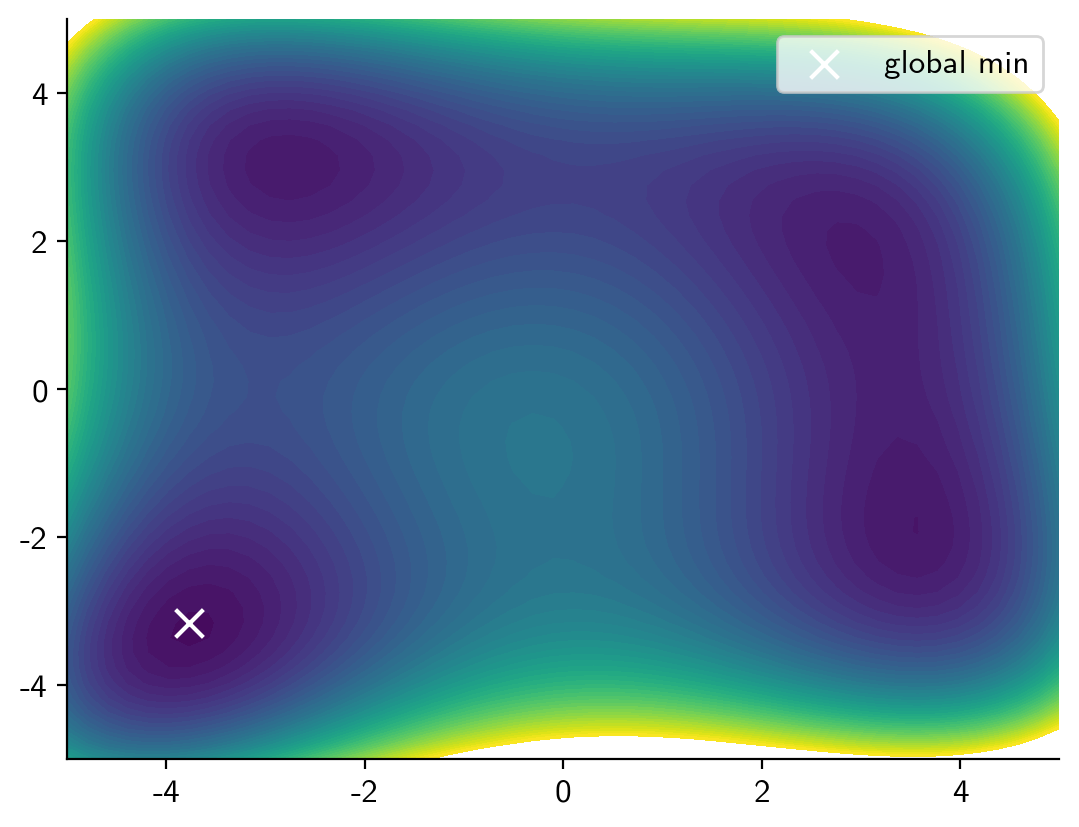

In [4]:
fig, ax = plt.subplots()

xx, yy, XY_grid = create_grid()
zz = himmelblau(XY_grid).reshape(xx.shape)

levels = np.linspace(0, 500)

ax.contourf(xx, yy, zz, levels=levels, cmap="viridis")

xy_min = XY_grid[np.argmin(zz)]
ax.scatter(xy_min[0], xy_min[1], c="w", s=100, marker="x", label="global min")

ax.legend()

plt.show()

## Defining the active learning loop

To define the active learning loop, we need to define: an acquisition function, the Bayesian optimization loop, and the GPR training process.
We do all three in the loops below

In [5]:
def acquisition_fn(X, X_sample, Y_sample, gpr, xi=0.01):
    """
    Computes the Expected Improvement at points X, given existing samples (X_sample, Y_sample),
    a Gaussian Process model gpr, and exploration parameter xi.
    """
    mu, sigma = gpr.predict(X, return_std=True)
    
    # objective: minimize the function
    known_optimum = np.min(Y_sample)
    
    # We transform the problem as if maximizing the negative cost, so we use a "gain" definition:
    # improvement = mu_sample_opt - mu - xi. (Because we want to go lower than the best known point.)
    improvement = known_optimum - mu - xi
    
    Z = improvement / sigma
    # EI = E[max(0, improvement)] under a normal distribution assumption
    #     = (improvement)*CDF(Z) + sigma*PDF(Z)
    # where CDF and PDF of the standard normal distribution.
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0  # Avoid division by zero
    return ei

In [6]:
def bayesian_optimization_himmelblau(n_init=5, n_iter=15, xi=0.01, num_candidates=1, bounds=BOUNDS):
    """
    Runs Bayesian optimization on Himmelblau's function with an EI acquisition function.
    Returns:
      - X_samples_all: list of arrays containing the sampled X at each iteration
      - Y_samples_all: list of arrays containing the sampled Y at each iteration
      - gprs: list of fitted GPR models after each iteration
      - bounds: array with shape (2, 2) for plotting
    """
    
    # 3.a. Generate initial samples
    np.random.seed(55)
    X_sample = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_init, 2))
    Y_sample = himmelblau(X_sample)
    
    # Store the progression of the model and samples at each iteration
    X_samples_all = [X_sample.copy()]
    Y_samples_all = [Y_sample.copy()]
    gprs = []
    
    # Create a grid for this example
    _, _, XY_grid = create_grid()
    
    # Run the optimization loop
    for iteration in range(n_iter):
        
        # Fit GP to current samples
        kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0) + WhiteKernel()
        gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True)
        gpr.fit(X_sample, Y_sample)
        
        # Store the fitted model
        gprs.append(gpr)
        
        # Selection of the next candidates: either random or with a grid
        # X_cand = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(num_candidates, bounds.shape[0]))
        X_cand = XY_grid
        
        # Computing the expected improvement and getting the next point
        acquisition_values = acquisition_fn(X_cand, X_sample, Y_sample, gpr, xi)
        x_next = X_cand[np.argmax(acquisition_values)]
        
        # Evaluate objective at proposed location
        y_next = himmelblau(x_next.reshape(1, -1))
        
        # Augment training dataset
        X_sample = np.vstack([X_sample, x_next])
        Y_sample = np.concatenate([Y_sample, y_next])
        
        # Store
        X_samples_all.append(X_sample.copy())
        Y_samples_all.append(Y_sample.copy())
    
    return X_samples_all, Y_samples_all, gprs, bounds

In [7]:
X_samples_all, Y_samples_all, gprs, bounds = bayesian_optimization_himmelblau(
    n_init=10,
    n_iter=50,
    xi=1,
)

/opt/miniforge3/envs/ml4mat/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/miniforge3/envs/ml4mat/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/miniforge3/envs/ml4mat/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/miniforge3/envs/ml4mat/lib/python3.1

/opt/miniforge3/envs/ml4mat/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/miniforge3/envs/ml4mat/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/miniforge3/envs/ml4mat/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/miniforge3/envs/ml4mat/lib/p

## Visualizing the outcomes

In [8]:
def plot_iteration(iteration, xi=0.01):
    # iteration goes from 0 to len(gprs)-1
    gpr = gprs[iteration]
    X_sample = X_samples_all[iteration+1]
    Y_sample = Y_samples_all[iteration+1]
    
    # Create a grid over the domain
    xx, yy, XY_grid = create_grid(resolution=50)
    
    # Predict the mean with the GP
    mu, std = gpr.predict(XY_grid, return_std=True)
    mu = mu.reshape(xx.shape)
    std = std.reshape(xx.shape)
    
    # Compute acquisition function
    ei = acquisition_fn(XY_grid, X_sample, Y_sample, gpr, xi=xi)
    ei = ei.reshape(xx.shape)
    
    x_next = XY_grid[np.argmax(ei)]
    
    # Computing the ground truth for this example
    # in practice, we can't compute the ground truth like this
    zz = himmelblau(XY_grid).reshape(xx.shape)
    xy_min = XY_grid[np.argmin(zz)]
    
    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # -- Left: Predicted mean of the objective
    ax = axes[0]
    norm = plt.Normalize(0, 600)
    cf1 = ax.contourf(xx, yy, mu, levels=50, cmap='viridis', norm=norm)
    ax.scatter(X_sample[:, 0], X_sample[:, 1], c='red', s=50, label='Samples')
    ax.scatter(x_next[0], x_next[1], c='magenta', s=100, label='Next')
    ax.scatter(xy_min[0], xy_min[1], c="w", s=100, marker="x", label="global min")
    ax.set_title(f"GPR Mean Prediction (Iteration = {iteration})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(cf1, ax=ax)
    ax.legend()
    
    # -- Right: Acquisition function
    ax = axes[1]
    cf2 = ax.contourf(xx, yy, ei, levels=50, cmap='viridis')
    ax.scatter(X_sample[:, 0], X_sample[:, 1], c='red', s=50, label='Samples')
    ax.scatter(x_next[0], x_next[1], c='magenta', s=200, label='Next')
    ax.scatter(xy_min[0], xy_min[1], c="w", s=100, marker="x", label="global min")
    ax.set_title("Acquisition (Expected Improvement)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(cf2, ax=ax)
    
    plt.tight_layout()
    plt.show()

# Use ipywidgets.interact to create an interactive slider
slider_iteration = IntSlider(min=0, max=len(gprs)-1, step=1, value=0, description='Iteration')
slider_xi = FloatSlider(min=0.0, max=2000.0, step=100, value=0.01, description='xi')

interact(plot_iteration, iteration=slider_iteration, xi=slider_xi)

interactive(children=(IntSlider(value=0, description='Iteration', max=49), FloatSlider(value=0.01, description…

<function __main__.plot_iteration(iteration, xi=0.01)>